In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Ijazah1.jpg to Ijazah1.jpg
Saving Ijazah2.jpg to Ijazah2.jpg
Saving Ijazah3.jpg to Ijazah3.jpg
Saving Ijazah4.jpg to Ijazah4.jpg
Saving Ijazah5.jpg to Ijazah5.jpg
Saving Ijazah6.jpg to Ijazah6.jpg
Saving Ijazah7.jpg to Ijazah7.jpg
Saving Ijazah8.jpg to Ijazah8.jpg
Saving Ijazah9.jpg to Ijazah9.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
from google.colab import files

In [ ]:
os.makedirs("hasil/rgb_grayscale", exist_ok=True)
os.makedirs("hasil/histogram", exist_ok=True)
os.makedirs("hasil/enhancement", exist_ok=True)

print("Folder hasil berhasil dibuat.")

Folder hasil berhasil dibuat.


In [ ]:
print("Daftar gambar:")

for i, filename in enumerate(uploaded.keys(), start=1):
    print(f"{i}. {filename}")

Daftar gambar:
1. Ijazah1.jpg
2. Ijazah2.jpg
3. Ijazah3.jpg
4. Ijazah4.jpg
5. Ijazah5.jpg
6. Ijazah6.jpg
7. Ijazah7.jpg
8. Ijazah8.jpg
9. Ijazah9.jpg


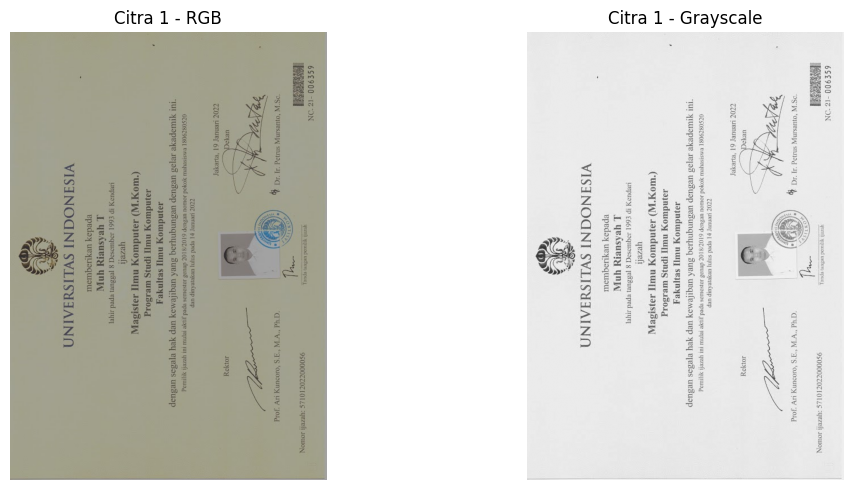

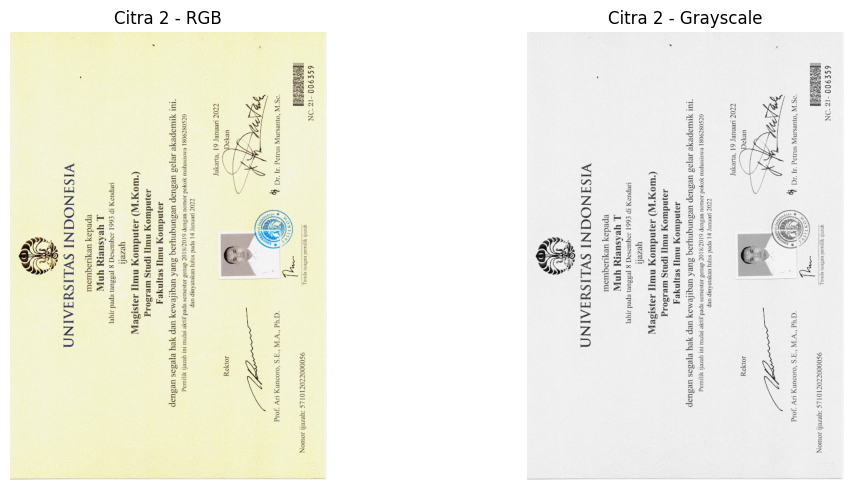

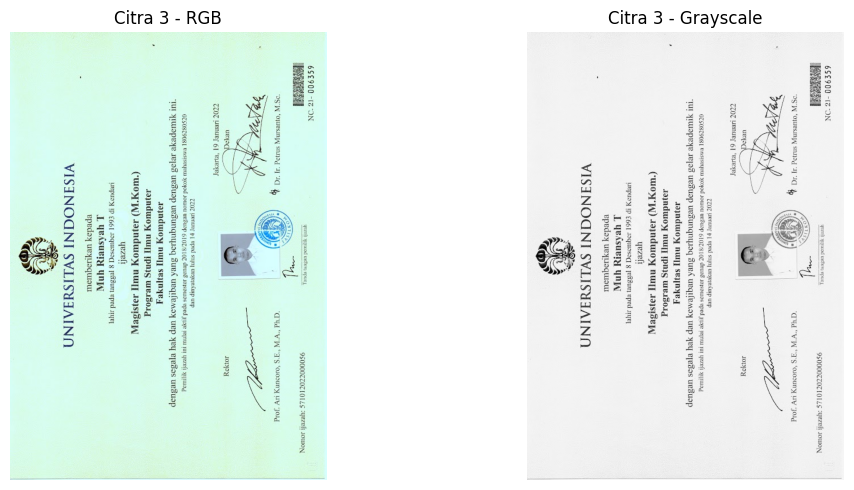

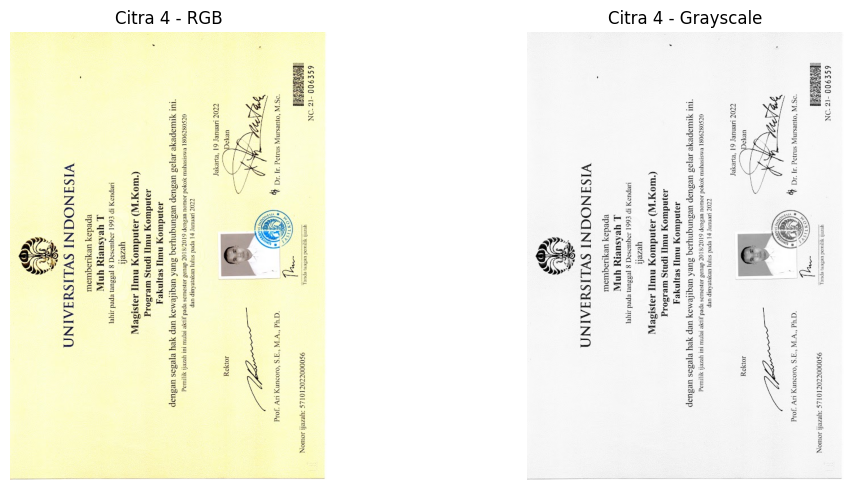

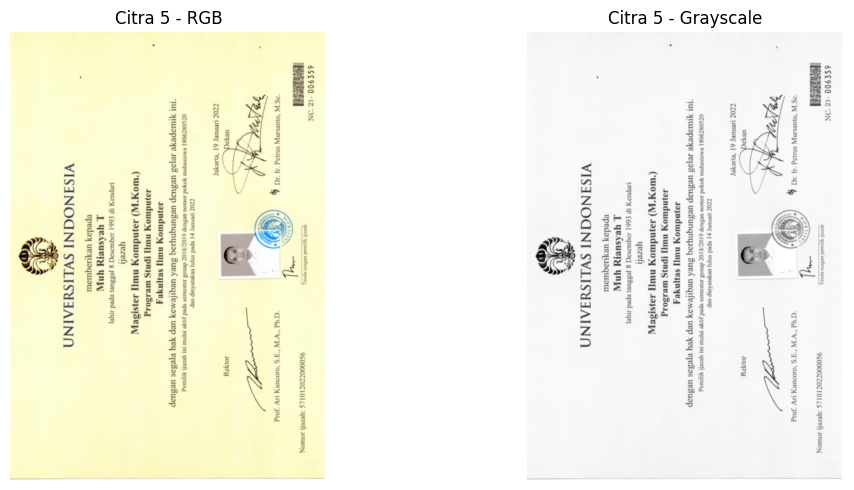

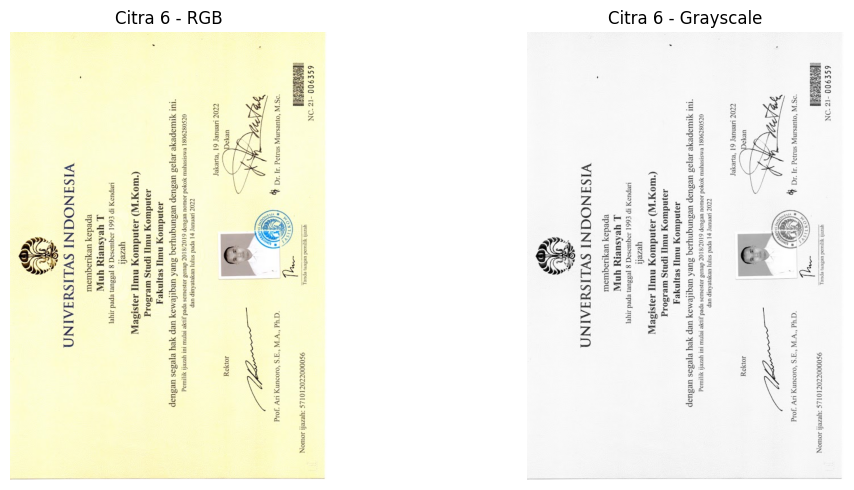

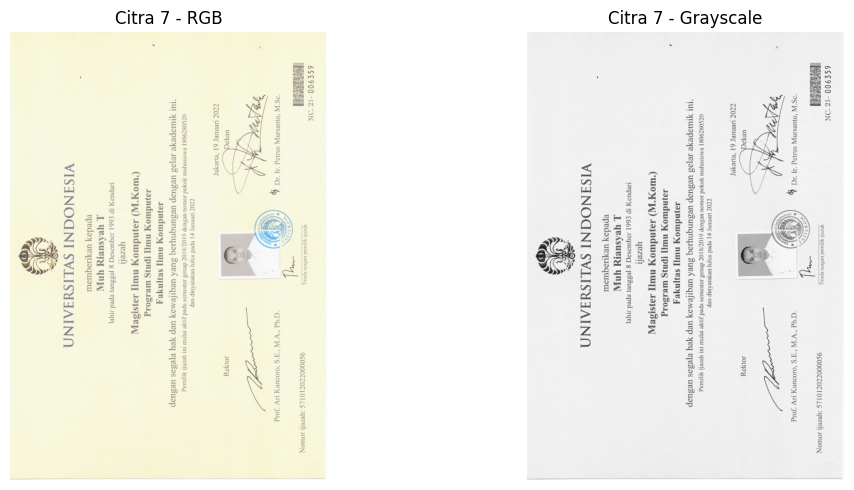

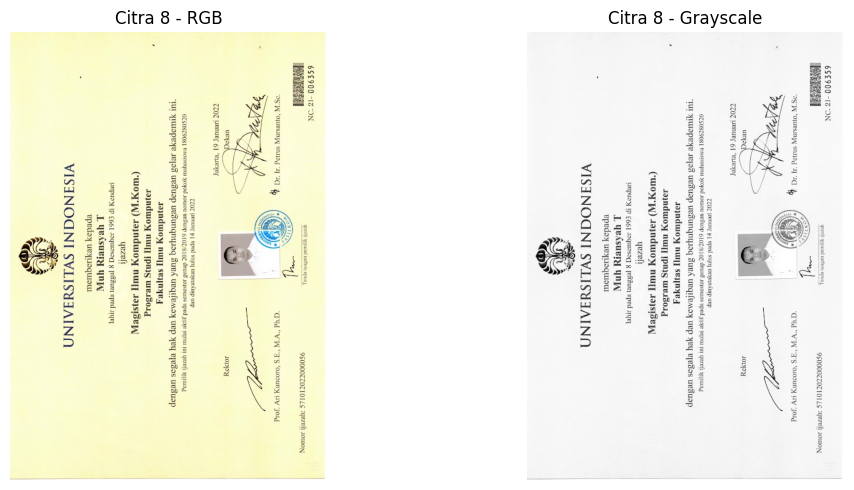

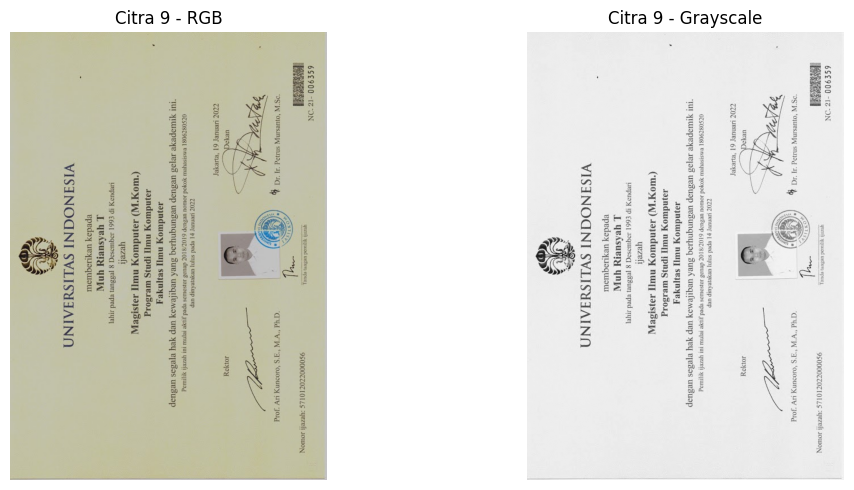

In [ ]:
for i, filename in enumerate(uploaded.keys(), start=1):

    img = cv2.imread(filename)

    if img is None:
        print(f"Gagal membaca: {filename}")
        continue

    # OpenCV membaca BGR
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Konversi ke grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Tampilkan
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f"Citra {i} - RGB")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(gray, cmap="gray")
    plt.title(f"Citra {i} - Grayscale")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Simpan grayscale
    cv2.imwrite(
        f"hasil/rgb_grayscale/citra_{i}_grayscale.jpg",
        gray
    )

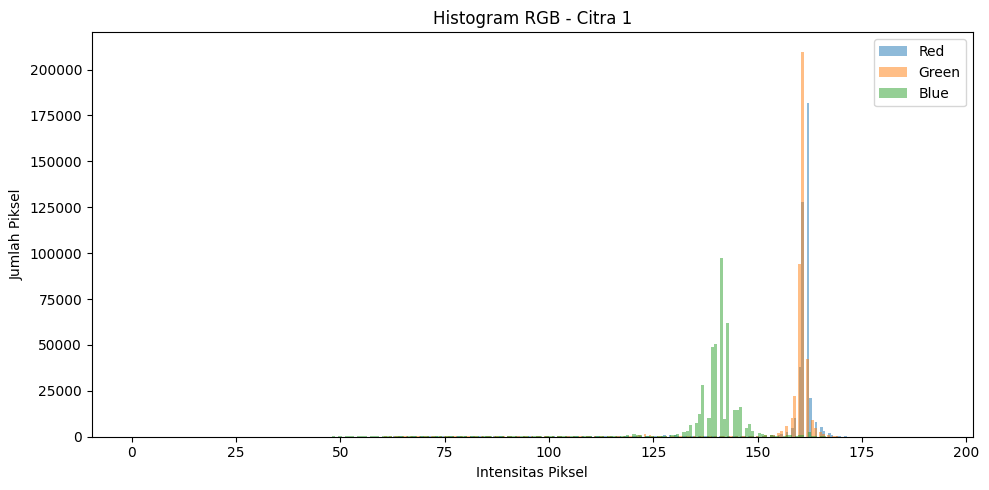

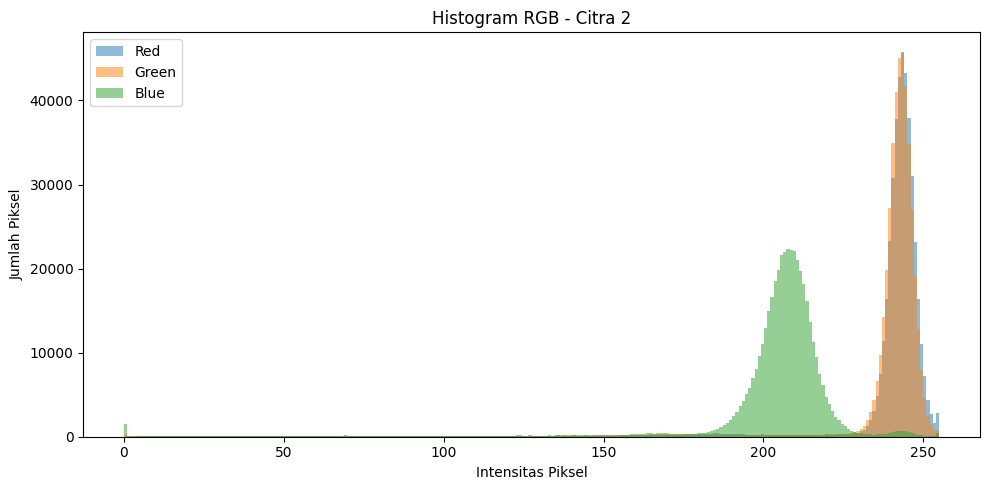

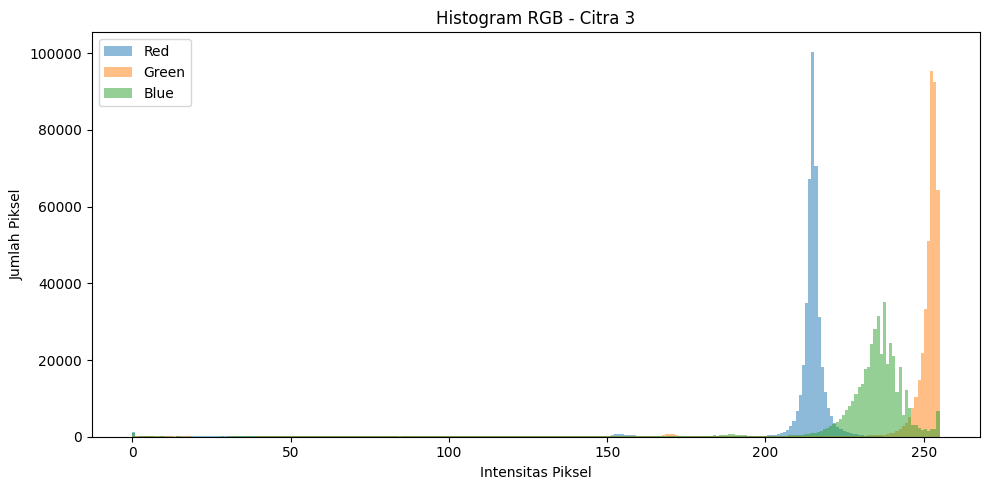

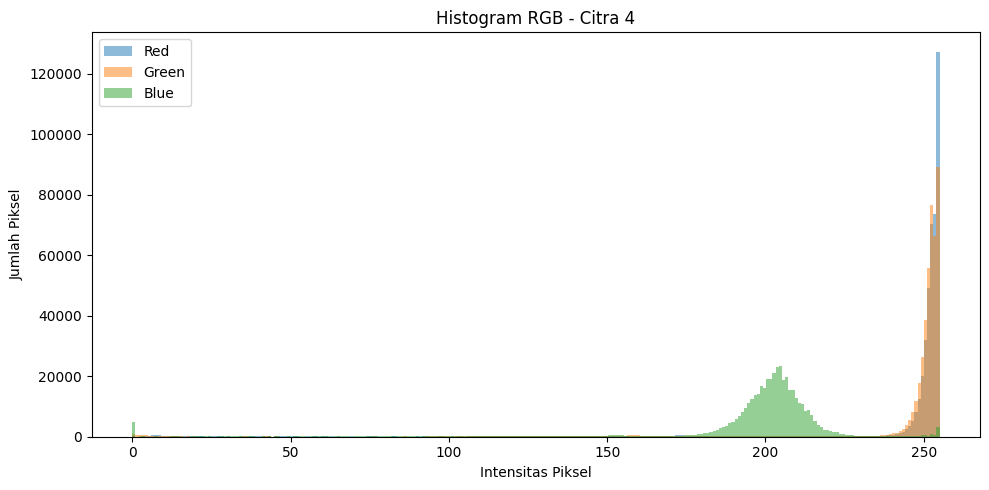

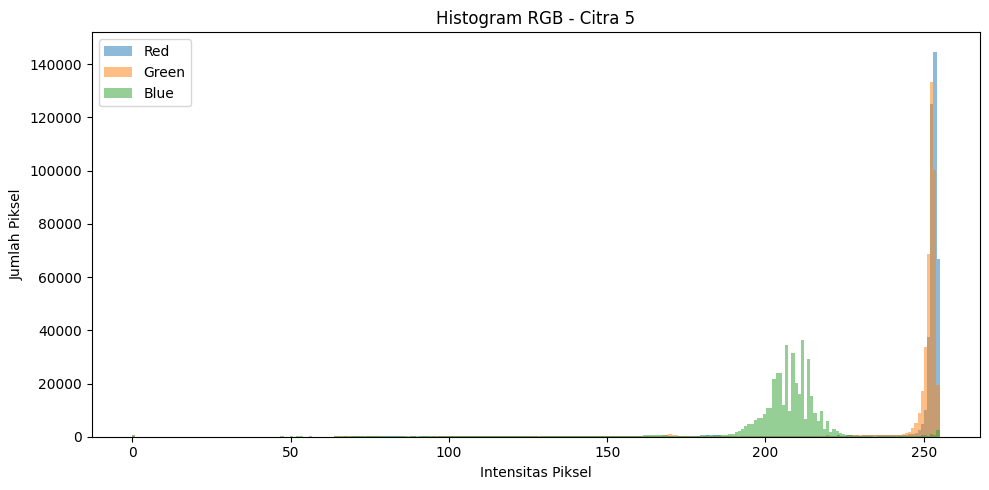

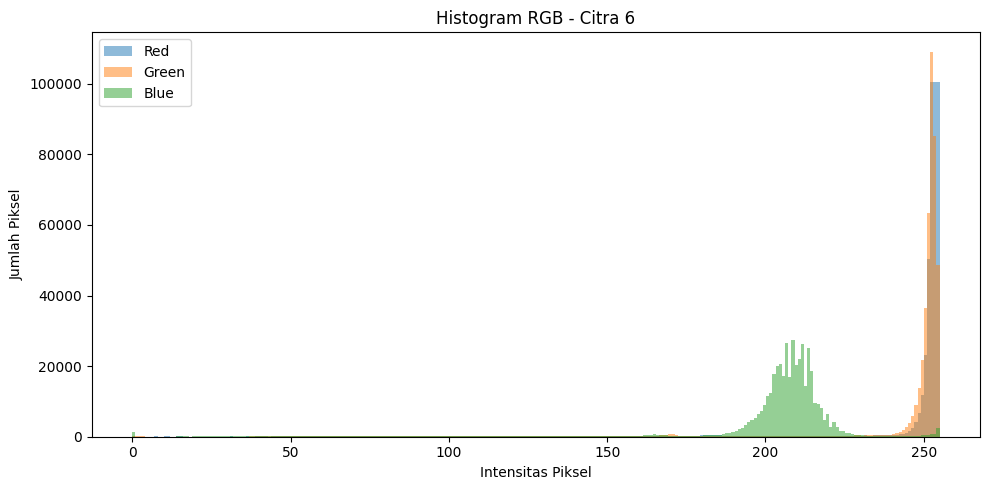

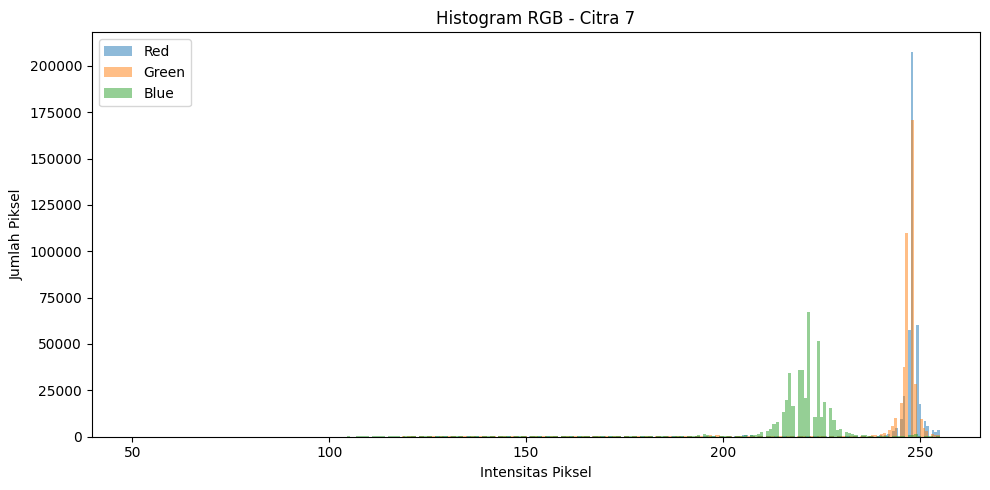

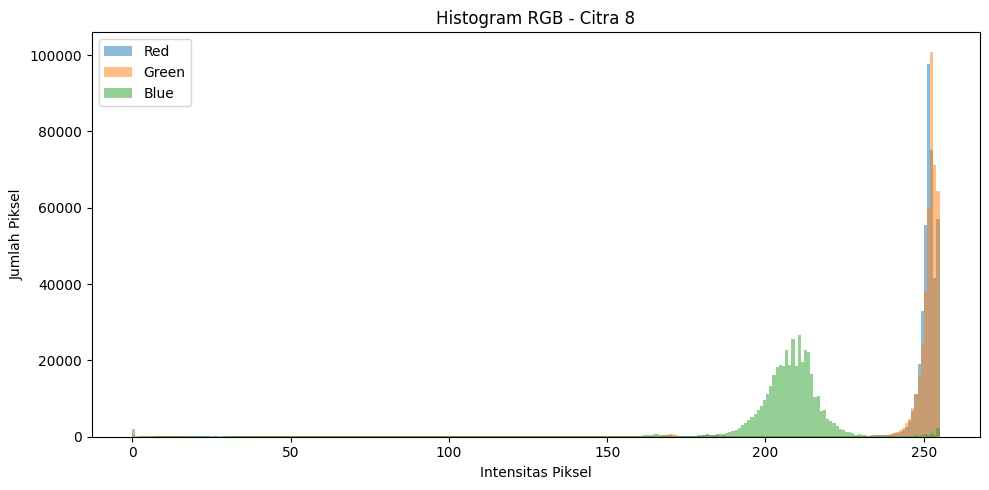

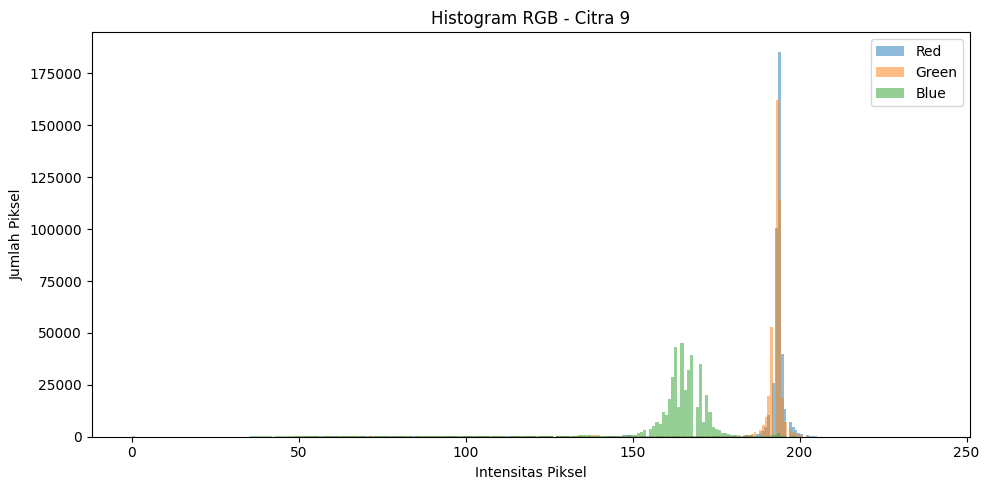

In [ ]:
for i, filename in enumerate(uploaded.keys(), start=1):

    img = cv2.imread(filename)

    if img is None:
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))

    plt.hist(
        img_rgb[:, :, 0].ravel(),
        bins=256,
        alpha=0.5,
        label="Red"
    )

    plt.hist(
        img_rgb[:, :, 1].ravel(),
        bins=256,
        alpha=0.5,
        label="Green"
    )

    plt.hist(
        img_rgb[:, :, 2].ravel(),
        bins=256,
        alpha=0.5,
        label="Blue"
    )

    plt.title(f"Histogram RGB - Citra {i}")
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.legend()

    plt.tight_layout()

    # Simpan
    plt.savefig(
        f"hasil/histogram/citra_{i}_histogram_rgb.png",
        dpi=150
    )

    plt.show()

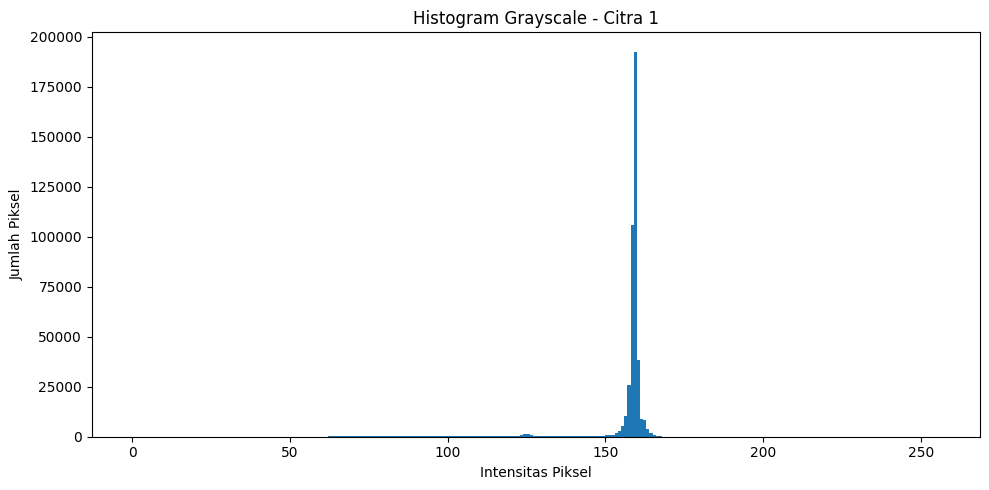

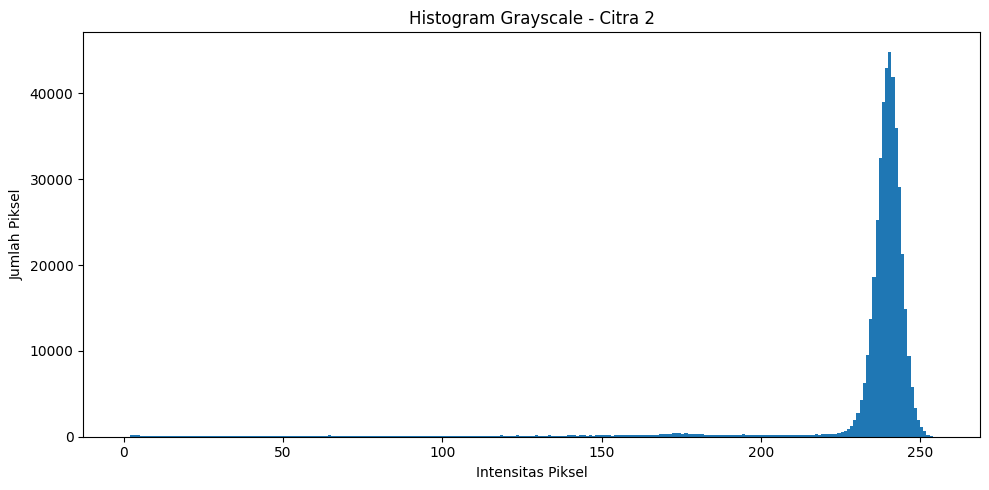

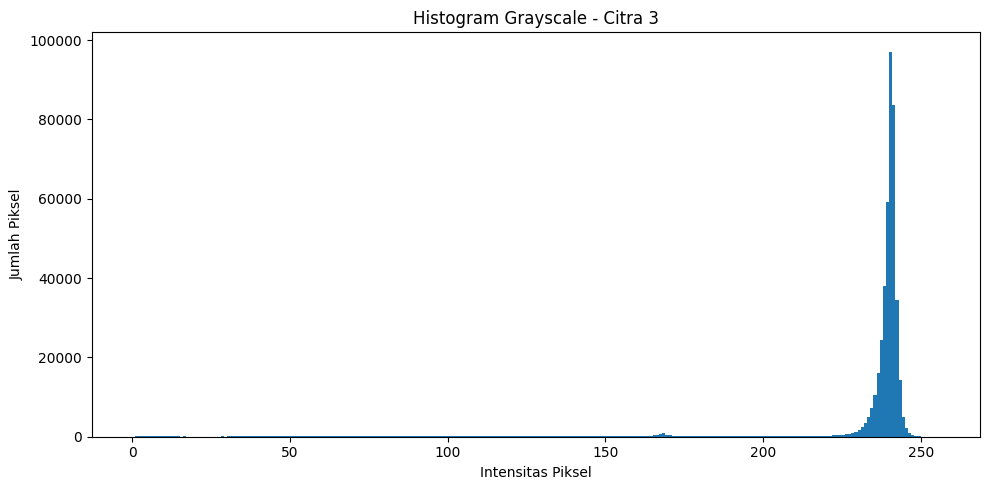

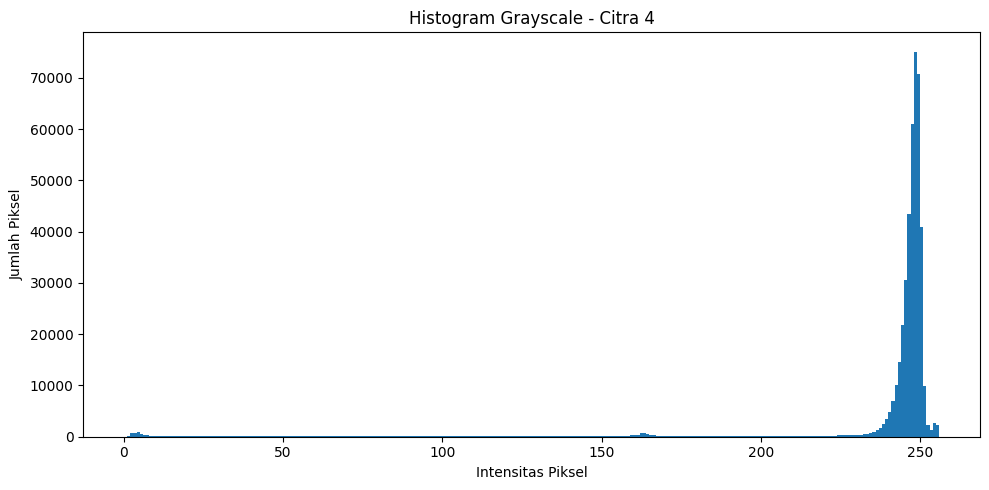

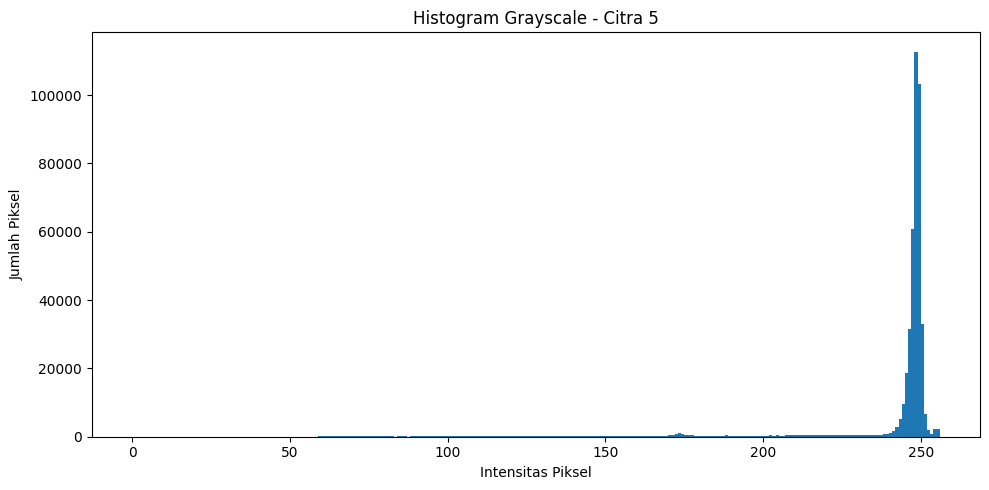

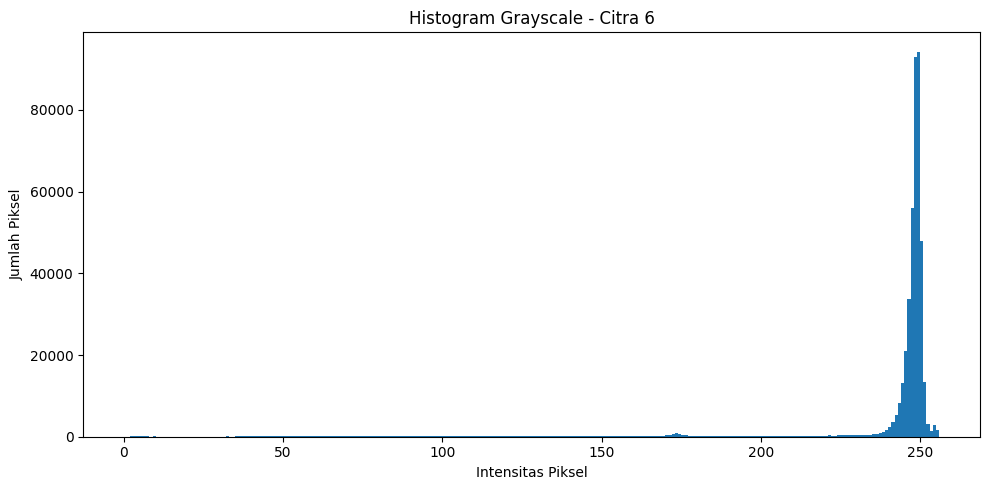

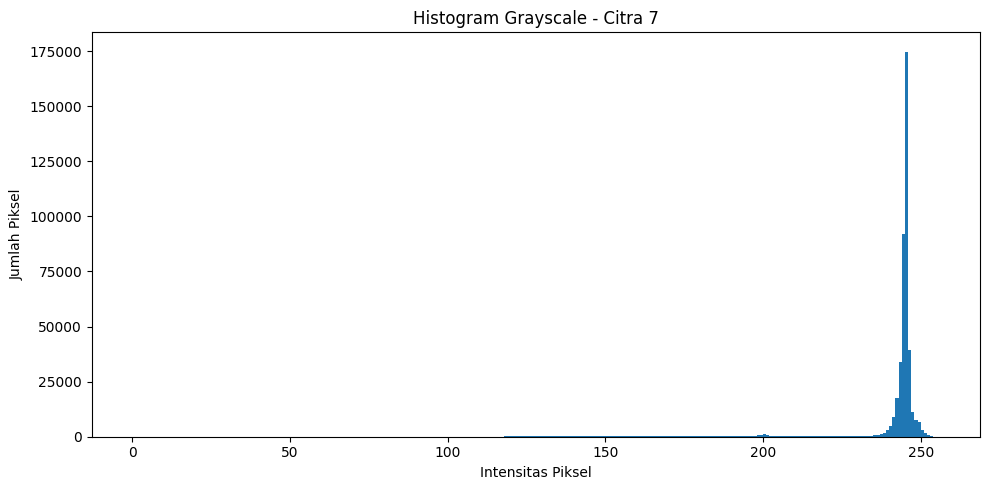

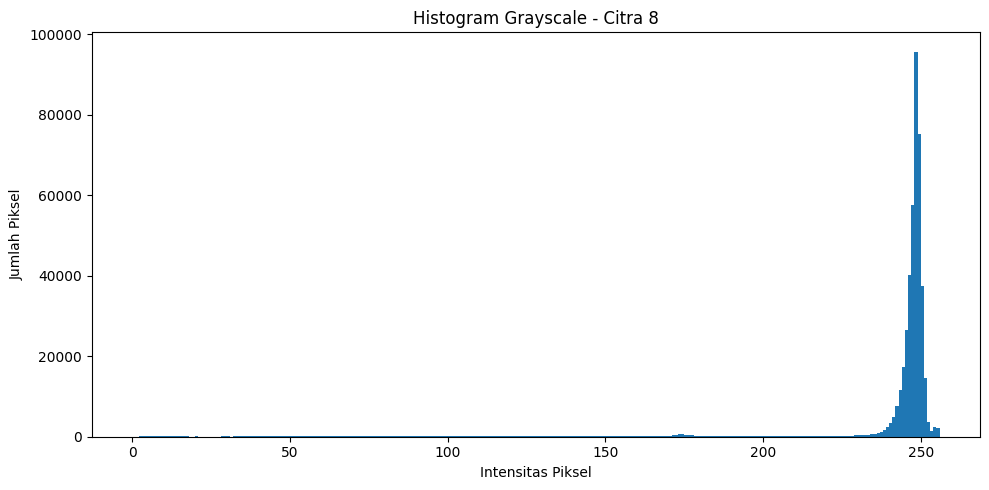

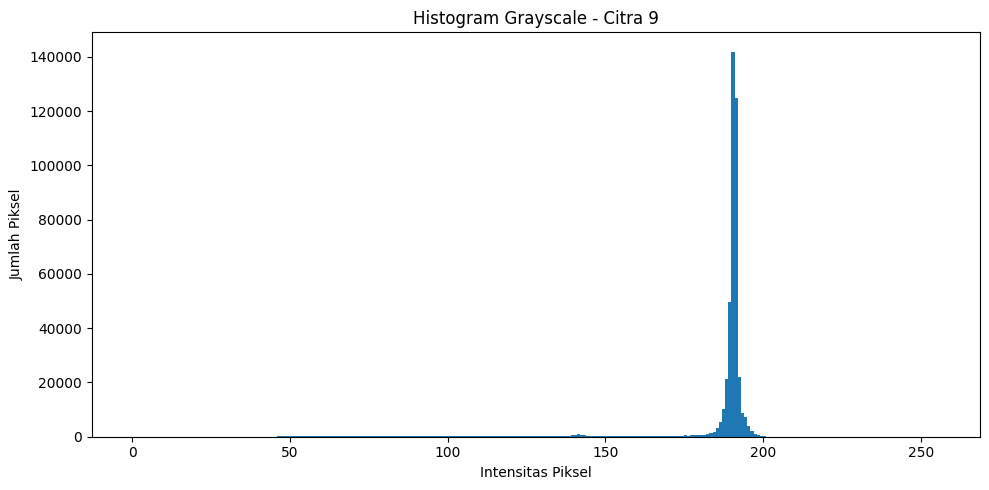

In [ ]:
for i, filename in enumerate(uploaded.keys(), start=1):

    img = cv2.imread(filename)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(10, 5))

    plt.hist(
        gray.ravel(),
        bins=256,
        range=[0, 256]
    )

    plt.title(f"Histogram Grayscale - Citra {i}")
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")

    plt.tight_layout()

    plt.savefig(
        f"hasil/histogram/citra_{i}_histogram_grayscale.png",
        dpi=150
    )

    plt.show()

In [ ]:
for i, filename in enumerate(uploaded.keys(), start=1):

    img = cv2.imread(filename)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mean_val = np.mean(gray)
    std_val = np.std(gray)
    min_val = np.min(gray)
    max_val = np.max(gray)

    print(f"\nCitra {i} - {filename}")
    print(f"Mean     : {mean_val:.2f}")
    print(f"Std      : {std_val:.2f}")
    print(f"Minimum  : {min_val}")
    print(f"Maksimum : {max_val}")


Citra 1 - Ijazah1.jpg
Mean     : 154.96
Std      : 15.07
Minimum  : 13
Maksimum : 172

Citra 2 - Ijazah2.jpg
Mean     : 231.96
Std      : 31.44
Minimum  : 0
Maksimum : 255

Citra 3 - Ijazah3.jpg
Mean     : 231.42
Std      : 32.48
Minimum  : 0
Maksimum : 252

Citra 4 - Ijazah4.jpg
Mean     : 237.87
Std      : 37.27
Minimum  : 0
Maksimum : 255

Citra 5 - Ijazah5.jpg
Mean     : 239.56
Std      : 28.83
Minimum  : 1
Maksimum : 255

Citra 6 - Ijazah6.jpg
Mean     : 239.21
Std      : 32.98
Minimum  : 0
Maksimum : 255

Citra 7 - Ijazah7.jpg
Mean     : 239.63
Std      : 19.83
Minimum  : 73
Maksimum : 255

Citra 8 - Ijazah8.jpg
Mean     : 239.06
Std      : 33.72
Minimum  : 0
Maksimum : 255

Citra 9 - Ijazah9.jpg
Mean     : 184.58
Std      : 22.14
Minimum  : 1
Maksimum : 205


In [ ]:
def contrast_stretching(image):
    min_val = np.min(image)
    max_val = np.max(image)

    if max_val == min_val:
        return image

    stretched = (
        (image - min_val) /
        (max_val - min_val) * 255
    )

    return stretched.astype(np.uint8)



In [ ]:
def clahe_enhancement(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(image)
    return enhanced_image

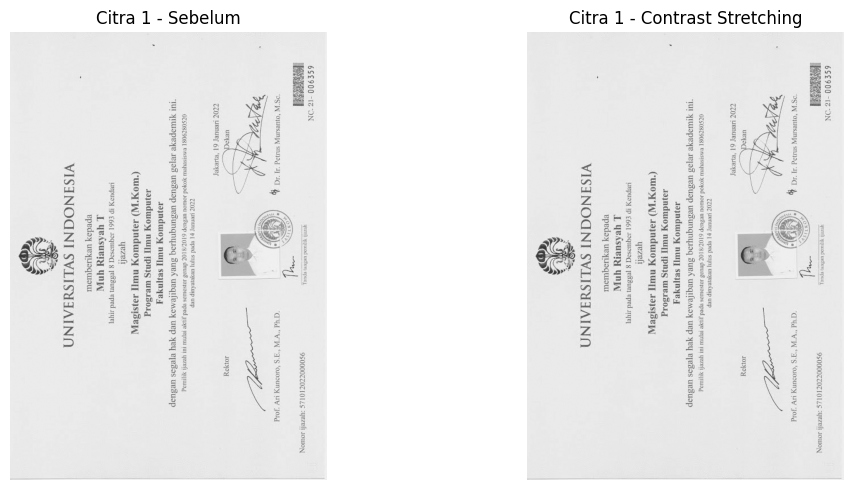

In [ ]:
img1 = cv2.imread("Ijazah1.jpg", cv2.IMREAD_GRAYSCALE)

hasil1 = contrast_stretching(img1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img1, cmap="gray")
plt.title("Citra 1 - Sebelum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil1, cmap="gray")
plt.title("Citra 1 - Contrast Stretching")
plt.axis("off")

plt.tight_layout()
plt.show()

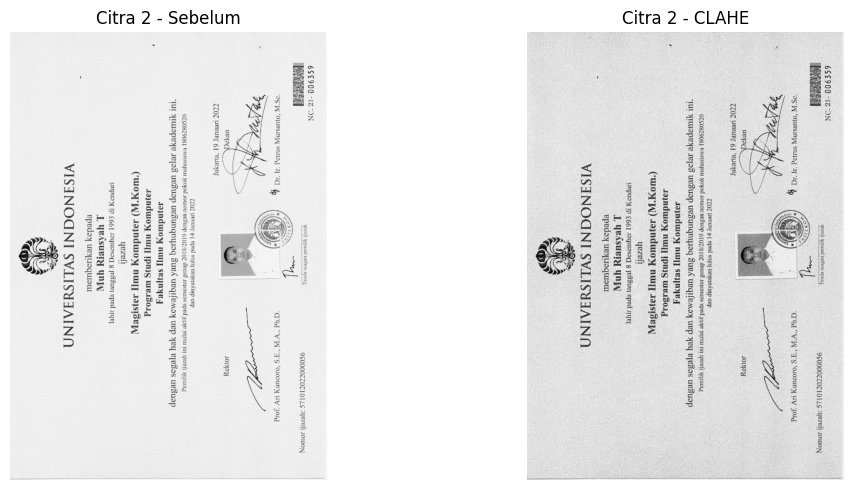

In [ ]:
img2 = cv2.imread("Ijazah2.jpg", cv2.IMREAD_GRAYSCALE)

hasil2 = clahe_enhancement(img2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img2, cmap="gray")
plt.title("Citra 2 - Sebelum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil2, cmap="gray")
plt.title("Citra 2 - CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

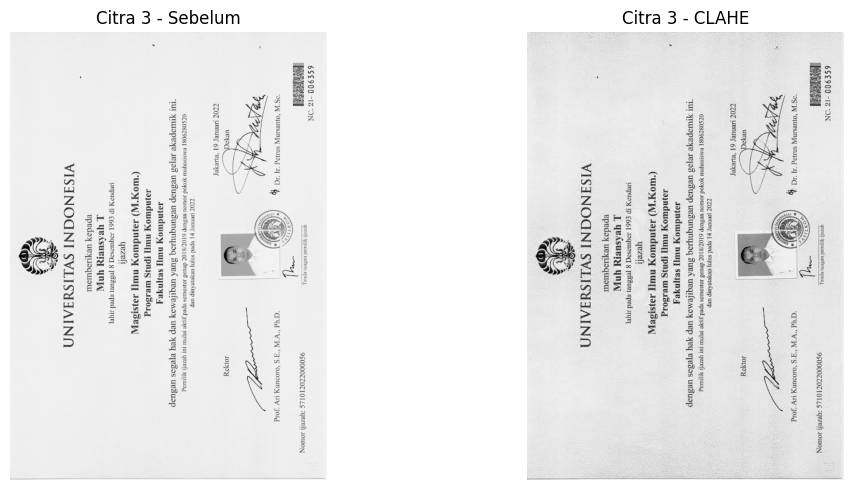

In [ ]:
img3 = cv2.imread("Ijazah3.jpg", cv2.IMREAD_GRAYSCALE)

hasil3 = clahe_enhancement(img3)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img3, cmap="gray")
plt.title("Citra 3 - Sebelum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil3, cmap="gray")
plt.title("Citra 3 - CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

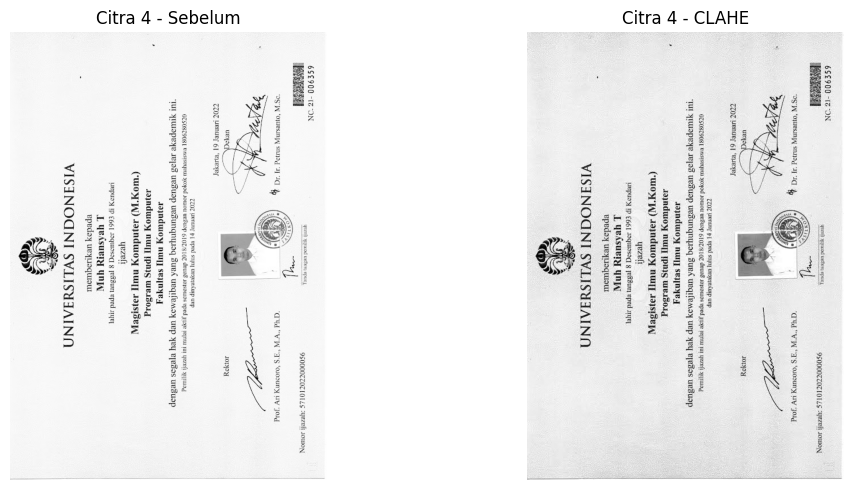

In [ ]:
img4 = cv2.imread("Ijazah4.jpg", cv2.IMREAD_GRAYSCALE)

hasil4 = clahe_enhancement(img4)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img4, cmap="gray")
plt.title("Citra 4 - Sebelum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil4, cmap="gray")
plt.title("Citra 4 - CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

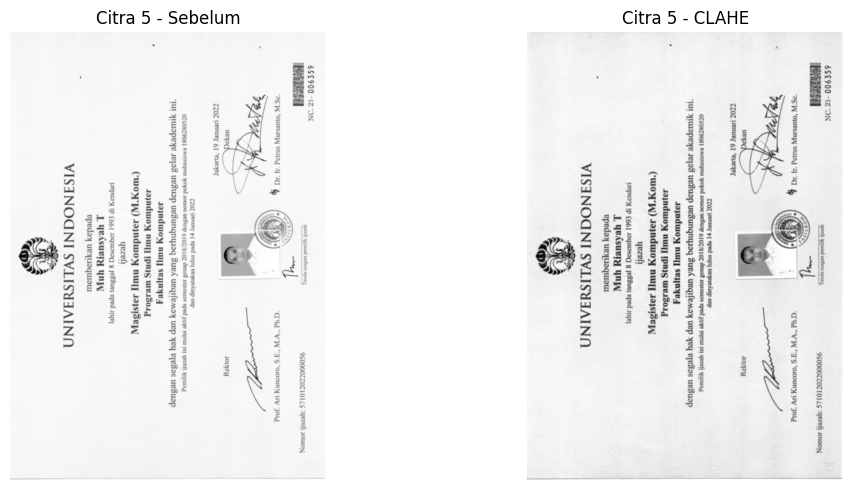

In [ ]:
img5 = cv2.imread("Ijazah5.jpg", cv2.IMREAD_GRAYSCALE)

hasil5 = clahe_enhancement(img5)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img5, cmap="gray")
plt.title("Citra 5 - Sebelum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil5, cmap="gray")
plt.title("Citra 5 - CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

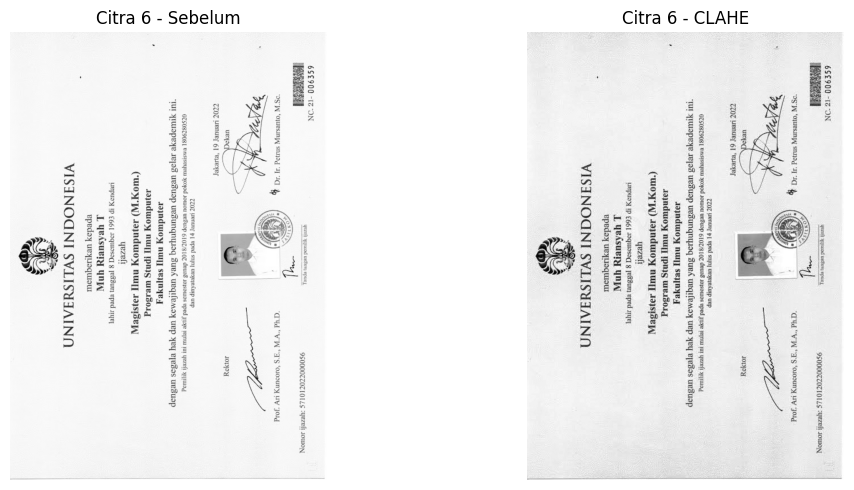

In [ ]:
img6 = cv2.imread("Ijazah6.jpg", cv2.IMREAD_GRAYSCALE)

hasil6 = clahe_enhancement(img6)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img6, cmap="gray")
plt.title("Citra 6 - Sebelum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil6, cmap="gray")
plt.title("Citra 6 - CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

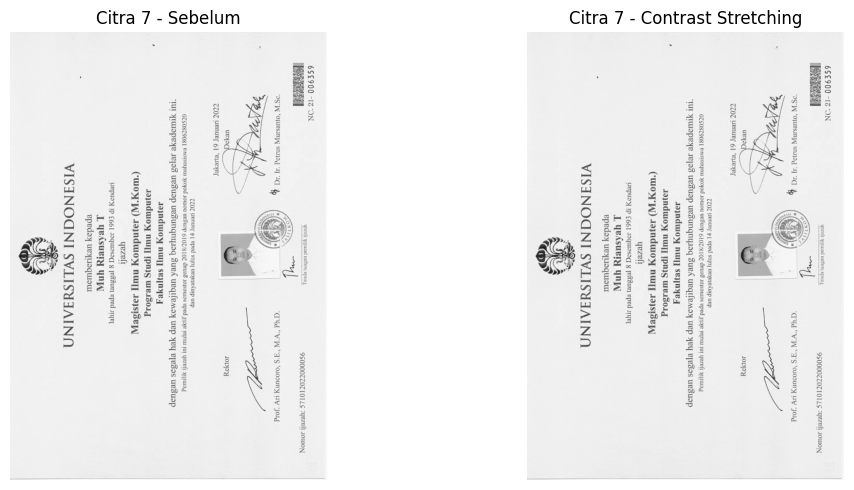

In [ ]:
img7 = cv2.imread("Ijazah7.jpg", cv2.IMREAD_GRAYSCALE)

hasil7 = contrast_stretching(img7)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img7, cmap="gray")
plt.title("Citra 7 - Sebelum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil7, cmap="gray")
plt.title("Citra 7 - Contrast Stretching")
plt.axis("off")

plt.tight_layout()
plt.show()

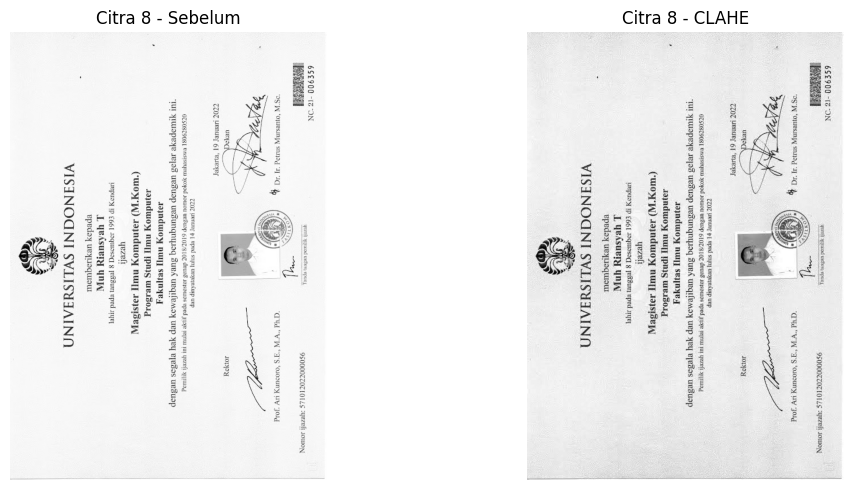

In [ ]:
img8 = cv2.imread("Ijazah8.jpg", cv2.IMREAD_GRAYSCALE)

hasil8 = clahe_enhancement(img8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img8, cmap="gray")
plt.title("Citra 8 - Sebelum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil8, cmap="gray")
plt.title("Citra 8 - CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

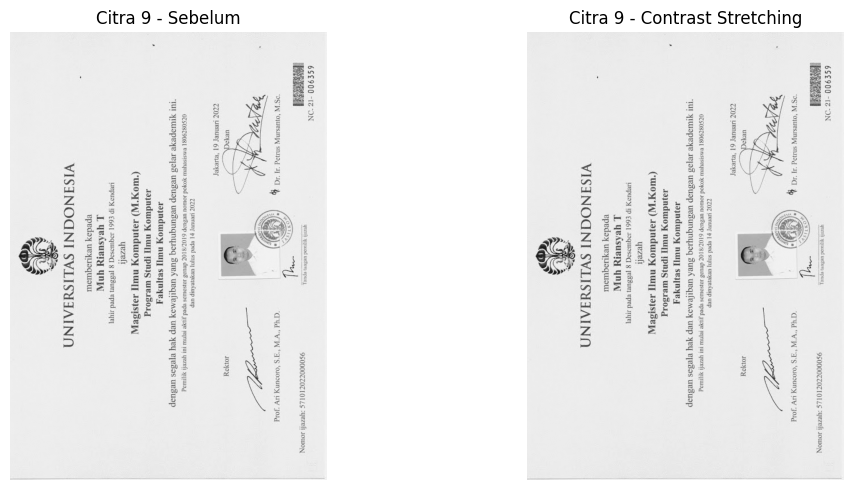

In [ ]:
img9 = cv2.imread("Ijazah9.jpg", cv2.IMREAD_GRAYSCALE)

hasil9 = contrast_stretching(img9)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img9, cmap="gray")
plt.title("Citra 9 - Sebelum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil9, cmap="gray")
plt.title("Citra 9 - Contrast Stretching")
plt.axis("off")

plt.tight_layout()
plt.show()